# Transfer Learning untuk Tiny GPT Gaming/FPS — Agar Tidak Menghafal 🎮

**Proyek Data Mining ST167 — Modul 9 (lanjutan: anti-hafalan).**

Notebook utama (`tinygpt_gaming.ipynb`) menunjukkan model **menghafal** korpus (train loss sangat
rendah, val loss tinggi, teks generate menyalin korpus). Notebook ini **mengurangi hafalan** dengan
**transfer learning (self-pretraining)** — **tetap Tiny GPT buatan sendiri dari nol** (bukan model
pra-terlatih raksasa), sehingga masih sesuai PPT Modul 9.

**Ide (transfer di dalam domain gaming):**
1. **PRETRAIN** Tiny GPT dari nol pada korpus **gaming umum** (`corpus_pretrain.txt`, ~12,7k kata).
2. **FINE-TUNE** model itu pada korpus **FPS** (`corpus_fps.txt`, ~5,7k kata) dengan setelan
   anti-hafalan: learning rate kecil, dropout lebih tinggi, sebagian lapisan **dibekukan**, dan
   **early stopping**.
3. **BASELINE** — latih dari nol pada FPS saja, sebagai pembanding "menghafal".

**Mengapa ini mengurangi hafalan:** model lebih dulu belajar pola bahasa gaming umum, jadi saat
fine-tune ke FPS ia tidak perlu menghafal teks FPS mentah-mentah. Kita ukur dengan **verbatim-overlap**
(berapa persen 8-kata hasil generate yang persis ada di korpus latih).

> Catatan jujur: data kita kecil, jadi efek transfer **sedang**, bukan dramatis. Obat sejati tetap
> "korpus jauh lebih besar". Tapi arah & teknik anti-hafalan-nya jelas terlihat di sini.

## 1. Setup & Deteksi GPU

In [1]:
import os, io, re, math, time, json, copy, collections
import torch, torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt
SEED=1337; torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("PyTorch:", torch.__version__, "| CUDA:", torch.cuda.is_available())
if device=="cuda":
    cap=torch.cuda.get_device_capability(0)
    print("GPU:", torch.cuda.get_device_name(0), "| sm_%d%d"%cap)
    torch.backends.cuda.matmul.allow_tf32=True; torch.backends.cudnn.allow_tf32=True
print("Perangkat dipakai:", device.upper())
OUT=os.path.join(os.getcwd(),"outputs"); os.makedirs(OUT, exist_ok=True)

PyTorch: 2.11.0+cu128 | CUDA: True
GPU: NVIDIA GeForce RTX 5060 Laptop GPU | sm_120
Perangkat dipakai: CUDA


## 2. Korpus: Gaming Umum (pretrain) vs FPS (fine-tune)

`corpus_pretrain.txt` = paragraf gaming **umum** (genre, sejarah, hardware, esports, industri, dll).
`corpus_fps.txt` = paragraf **khusus FPS** (mekanik, senjata, mode, game FPS). Keduanya berasal dari
korpus gaming yang sama, dipisah berdasarkan topik. FPS dibagi 90% train / 10% validasi.

In [2]:
pretrain_text = io.open("corpus_pretrain.txt", encoding="utf-8").read()
fps_text      = io.open("corpus_fps.txt", encoding="utf-8").read()
cut = int(0.9*len(fps_text))
fps_train_text, fps_val_text = fps_text[:cut], fps_text[cut:]
VAL_CHARS = len(fps_val_text)   # penyebut tetap utk bits/char
print(f"PRETRAIN gaming umum : {len(pretrain_text.split()):,} kata | {len(pretrain_text):,} char")
print(f"FINE-TUNE FPS        : {len(fps_text.split()):,} kata | train {len(fps_train_text):,} char | val {len(fps_val_text):,} char")

PRETRAIN gaming umum : 12,716 kata | 96,628 char
FINE-TUNE FPS        : 5,748 kata | train 38,792 char | val 4,311 char


## 3. Tokenizer Subword (BPE) — satu untuk semua tahap

Transfer learning butuh **tokenizer/vocab yang sama** di pretrain & fine-tune. Kita pakai **BPE
(subword)** yang di-`fit` pada gabungan teks (gaming umum + FPS) supaya vocab mencakup keduanya.
Subword juga membuat model **tidak pernah memunculkan `<unk>`** untuk kata baru.

In [3]:
class BPETokenizer:
    name="bpe"
    def __init__(self, num_merges=500): self.num_merges=num_merges
    def fit(self, text):
        words=re.findall(r"[a-zA-Z]+", text.lower())
        vocab=collections.Counter(" ".join(list(w))+" </w>" for w in words)
        merges=[]
        for _ in range(self.num_merges):
            pairs=collections.Counter()
            for w,f in vocab.items():
                s=w.split()
                for j in range(len(s)-1): pairs[(s[j],s[j+1])]+=f
            if not pairs: break
            best=max(pairs,key=pairs.get); merges.append(best)
            patt=re.compile(r"(?<!\S)"+re.escape(" ".join(best))+r"(?!\S)")
            vocab={patt.sub("".join(best),w):f for w,f in vocab.items()}
        self.ranks={p:i for i,p in enumerate(merges)}
        units=set()
        for w in re.findall(r"[a-zA-Z]+", text.lower()): units.update(self._enc(w))
        base=set(text.lower())
        vl=["<unk>"," "]+sorted(units|base|{"</w>"})
        self.stoi={t:i for i,t in enumerate(dict.fromkeys(vl))}
        self.itos={i:t for t,i in self.stoi.items()}
        self.vocab_size=len(self.stoi); return self
    def _enc(self, word):
        s=list(word)+["</w>"]
        while len(s)>1:
            best,br=None,None
            for i in range(len(s)-1):
                r=self.ranks.get((s[i],s[i+1]))
                if r is not None and (br is None or r<br): br,best=r,(s[i],s[i+1])
            if best is None: break
            m,i=[],0
            while i<len(s):
                if i<len(s)-1 and (s[i],s[i+1])==best: m.append(s[i]+s[i+1]); i+=2
                else: m.append(s[i]); i+=1
            s=m
        return s
    def encode(self, t):
        ids=[]
        for tok in re.findall(r"[a-zA-Z]+|\s+|[^a-zA-Z\s]", t.lower()):
            if tok.isspace(): ids.append(self.stoi.get(" ",0))
            elif tok.isalpha():
                for u in self._enc(tok): ids.append(self.stoi.get(u,0))
            else: ids.append(self.stoi.get(tok,0))
        return ids
    def decode(self, ids):
        return "".join(self.itos.get(i,"") for i in ids).replace("</w>"," ")

tok = BPETokenizer(num_merges=500).fit(pretrain_text + "\n" + fps_text)
pretrain_ids = torch.tensor(tok.encode(pretrain_text), dtype=torch.long)
fps_train_ids = torch.tensor(tok.encode(fps_train_text), dtype=torch.long)
fps_val_ids   = torch.tensor(tok.encode(fps_val_text), dtype=torch.long)
print(f"vocab BPE: {tok.vocab_size}")
print(f"token: pretrain {len(pretrain_ids):,} | fps_train {len(fps_train_ids):,} | fps_val {len(fps_val_ids):,}")
print("uji <unk>? encode 'machine learning aim recoil':", tok.decode(tok.encode("machine learning aim recoil")))

vocab BPE: 505
token: pretrain 39,935 | fps_train 16,550 | fps_val 1,871
uji <unk>? encode 'machine learning aim recoil': machine  learning  aim  recoil 


## 4. Arsitektur Tiny GPT (sama, dropout dapat diatur)

In [4]:
BLOCK_SIZE, EMBED_DIM, N_HEADS, N_LAYERS = 128, 256, 8, 6

class CausalSelfAttention(nn.Module):
    def __init__(s, e, h, d):
        super().__init__(); s.qkv=nn.Linear(e,3*e,bias=False); s.proj=nn.Linear(e,e)
        s.drop=nn.Dropout(d); s.h=h; s.hd=e//h; s.d=d
    def forward(s,x):
        B,T,C=x.shape; q,k,v=s.qkv(x).split(C,2)
        q=q.view(B,T,s.h,s.hd).transpose(1,2); k=k.view(B,T,s.h,s.hd).transpose(1,2); v=v.view(B,T,s.h,s.hd).transpose(1,2)
        y=F.scaled_dot_product_attention(q,k,v,is_causal=True,dropout_p=s.d if s.training else 0.0)
        return s.drop(s.proj(y.transpose(1,2).contiguous().view(B,T,C)))
class FeedForward(nn.Module):
    def __init__(s,e,d):
        super().__init__(); s.net=nn.Sequential(nn.Linear(e,4*e),nn.ReLU(),nn.Linear(4*e,e),nn.Dropout(d))
    def forward(s,x): return s.net(x)
class Block(nn.Module):
    def __init__(s,e,h,d):
        super().__init__(); s.sa=CausalSelfAttention(e,h,d); s.ff=FeedForward(e,d)
        s.n1=nn.LayerNorm(e); s.n2=nn.LayerNorm(e)
    def forward(s,x): x=x+s.sa(s.n1(x)); return x+s.ff(s.n2(x))
class TinyGPT(nn.Module):
    def __init__(s, vocab, dropout=0.2):
        super().__init__()
        s.tok_emb=nn.Embedding(vocab,EMBED_DIM); s.pos_emb=nn.Embedding(BLOCK_SIZE,EMBED_DIM)
        s.blocks=nn.ModuleList([Block(EMBED_DIM,N_HEADS,dropout) for _ in range(N_LAYERS)])
        s.ln_f=nn.LayerNorm(EMBED_DIM); s.head=nn.Linear(EMBED_DIM,vocab)
    def forward(s, idx, targets=None):
        B,T=idx.shape; x=s.tok_emb(idx)+s.pos_emb(torch.arange(T,device=idx.device))
        for b in s.blocks: x=b(x)
        logits=s.head(s.ln_f(x)); loss=None
        if targets is not None:
            B,T,V=logits.shape; loss=F.cross_entropy(logits.view(B*T,V), targets.view(B*T))
        return logits, loss
    @torch.no_grad()
    def generate(s, idx, n_new, temperature=0.8, top_p=0.9, repetition_penalty=1.3):
        for _ in range(n_new):
            logits,_=s(idx[:,-BLOCK_SIZE:]); logits=logits[:,-1,:]
            if repetition_penalty and repetition_penalty!=1.0:
                for b in range(idx.size(0)):
                    seen=torch.unique(idx[b]); sc=logits[b,seen]
                    logits[b,seen]=torch.where(sc>0, sc/repetition_penalty, sc*repetition_penalty)
            logits=logits/temperature
            if top_p and top_p<1.0:
                sl,si=torch.sort(logits,descending=True,dim=-1)
                cum=torch.cumsum(F.softmax(sl,dim=-1),dim=-1); drop=cum>top_p
                drop[...,1:]=drop[...,:-1].clone(); drop[...,0]=False
                for b in range(logits.size(0)): logits[b,si[b,drop[b]]]=-float("inf")
            p=F.softmax(logits,dim=-1); idx=torch.cat([idx,torch.multinomial(p,1)],dim=1)
        return idx
print("Arsitektur siap. block=%d embed=%d heads=%d layers=%d"%(BLOCK_SIZE,EMBED_DIM,N_HEADS,N_LAYERS))

Arsitektur siap. block=128 embed=256 heads=8 layers=6


## 5. Utilitas Pelatihan & Metrik Hafalan (verbatim-overlap)

In [5]:
BATCH=48; EVAL_ITERS=40
def batches(data, n):
    ix=torch.randint(len(data)-BLOCK_SIZE-1,(n,))
    x=torch.stack([data[i:i+BLOCK_SIZE] for i in ix]); y=torch.stack([data[i+1:i+BLOCK_SIZE+1] for i in ix])
    return x.to(device), y.to(device)
@torch.no_grad()
def estimate(model, splits):
    model.eval(); out={}
    for nm,data in splits.items():
        L=torch.zeros(EVAL_ITERS)
        for k in range(EVAL_ITERS):
            xb,yb=batches(data,BATCH); _,l=model(xb,yb); L[k]=l.item()
        out[nm]=L.mean().item()
    model.train(); return out
def lr_at(it, peak, iters, warmup, lo):
    if it<warmup: return peak*(it+1)/warmup
    pr=(it-warmup)/max(1,iters-warmup); return lo+0.5*(peak-lo)*(1+math.cos(math.pi*min(1.0,pr)))

def train(tag, train_ids, splits, iters, peak_lr, dropout, warmup, eval_int,
          init_state=None, freeze_first=0, early_stop=True):
    model=TinyGPT(tok.vocab_size, dropout=dropout).to(device)
    if init_state is not None: model.load_state_dict(init_state)
    # bekukan embedding + sebagian block (transfer: andalkan fitur pretrain)
    if freeze_first>0:
        for p in model.tok_emb.parameters(): p.requires_grad=False
        for p in model.pos_emb.parameters(): p.requires_grad=False
        for b in model.blocks[:freeze_first]:
            for p in b.parameters(): p.requires_grad=False
    trainable=[p for p in model.parameters() if p.requires_grad]
    n_all=sum(p.numel() for p in model.parameters()); n_tr=sum(p.numel() for p in trainable)
    opt=torch.optim.AdamW(trainable, lr=peak_lr, weight_decay=0.1)
    print(f"  [{tag}] param total {n_all:,} | trainable {n_tr:,} | dropout {dropout} | iters {iters} | lr {peak_lr}")
    hist=[]; best=float("inf"); best_it=0; best_state=None
    for it in range(iters+1):
        for g in opt.param_groups: g["lr"]=lr_at(it,peak_lr,iters,warmup,peak_lr*0.1)
        if it%eval_int==0:
            est=estimate(model,splits); hist.append((it,est["train"],est["val"])); flag=""
            if est["val"]<best: best,best_it=est["val"],it; best_state=copy.deepcopy(model.state_dict()); flag="  <- best"
            print(f"    {tag} iter {it:4d} | train {est['train']:.4f} | val {est['val']:.4f}{flag}")
        xb,yb=batches(train_ids,BATCH); _,loss=model(xb,yb)
        opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
    if early_stop and best_state is not None: model.load_state_dict(best_state)
    return model, dict(tag=tag, history=hist, best_val=best, best_iter=best_it,
                       final_train=hist[-1][1], final_val=hist[-1][2], n_trainable=n_tr)

def gen_text(model, seed, n=160, temp=0.8):
    ids=tok.encode(seed) or [0]
    ctx=torch.tensor([ids],dtype=torch.long,device=device)
    return tok.decode(model.generate(ctx,n,temperature=temp)[0].tolist())

def verbatim_overlap(model, ref_text, seeds, n=8, gen_len=160):
    w=ref_text.lower().split(); ref=set(tuple(w[i:i+n]) for i in range(len(w)-n+1))
    tot=cop=0; samples=[]
    for s in seeds:
        out=gen_text(model,s,gen_len); samples.append(out); gw=out.lower().split()
        for i in range(len(gw)-n+1):
            tot+=1
            if tuple(gw[i:i+n]) in ref: cop+=1
    return (100*cop/max(1,tot)), tot, samples
print("Siap. Metrik hafalan = % 8-gram hasil generate yang PERSIS ada di korpus latih FPS.")

Siap. Metrik hafalan = % 8-gram hasil generate yang PERSIS ada di korpus latih FPS.


## 6. Tahap 1 — PRETRAIN (gaming umum, dari nol)

In [6]:
t0=time.time()
splits_pre={"train":pretrain_ids,"val":pretrain_ids}  # pretrain: pantau loss pada data pretrain
pre_model, pre_info = train("PRE", pretrain_ids, splits_pre, iters=4000, peak_lr=1e-3,
                            dropout=0.2, warmup=200, eval_int=250, early_stop=False)
torch.save(pre_model.state_dict(), os.path.join(OUT,"ckpt_pretrain.pt"))
pretrain_state=copy.deepcopy(pre_model.state_dict())
print(f"  PRETRAIN selesai {time.time()-t0:.0f}s -> outputs/ckpt_pretrain.pt")

  [PRE] param total 5,026,297 | trainable 5,026,297 | dropout 0.2 | iters 4000 | lr 0.001


    PRE iter    0 | train 6.3711 | val 6.3703  <- best


    PRE iter  250 | train 2.5927 | val 2.5870  <- best


    PRE iter  500 | train 1.0921 | val 1.0892  <- best


    PRE iter  750 | train 0.3050 | val 0.3062  <- best


...

    PRE iter 3000 | train 0.0671 | val 0.0679  <- best


    PRE iter 3250 | train 0.0668 | val 0.0651  <- best


    PRE iter 3500 | train 0.0653 | val 0.0647  <- best


    PRE iter 3750 | train 0.0626 | val 0.0633  <- best


    PRE iter 4000 | train 0.0631 | val 0.0618  <- best
  PRETRAIN selesai 145s -> outputs/ckpt_pretrain.pt


## 7. Tahap 2 — FINE-TUNE ke FPS (transfer, anti-hafalan)

Mulai dari bobot pretrain, lalu latih di FPS dengan **LR kecil (3e-4)**, **dropout 0.3**,
**embedding + 3 block pertama dibekukan**, dan **early stopping** pada val FPS.

In [7]:
splits_fps={"train":fps_train_ids,"val":fps_val_ids}
ft_model, ft_info = train("FT", fps_train_ids, splits_fps, iters=1200, peak_lr=3e-4,
                          dropout=0.3, warmup=100, eval_int=100,
                          init_state=pretrain_state, freeze_first=3, early_stop=True)
torch.save(ft_model.state_dict(), os.path.join(OUT,"ckpt_finetune.pt"))
print(f"  FINE-TUNE selesai | best_val={ft_info['best_val']:.4f}@{ft_info['best_iter']}")

  [FT] param total 5,026,297 | trainable 2,497,273 | dropout 0.3 | iters 1200 | lr 0.0003


    FT iter    0 | train 4.6056 | val 4.3755  <- best


    FT iter  100 | train 1.8464 | val 2.2111  <- best


    FT iter  200 | train 1.1200 | val 2.2179


    FT iter  300 | train 0.6118 | val 2.3769


...

    FT iter  800 | train 0.0979 | val 2.9905


    FT iter  900 | train 0.0933 | val 3.0187


    FT iter 1000 | train 0.0908 | val 3.0239


    FT iter 1100 | train 0.0873 | val 3.0312


    FT iter 1200 | train 0.0868 | val 3.0263
  FINE-TUNE selesai | best_val=2.2111@100


## 8. Tahap 3 — BASELINE (FPS dari nol, pembanding hafalan)

In [8]:
sc_model, sc_info = train("SCR", fps_train_ids, splits_fps, iters=1200, peak_lr=1e-3,
                          dropout=0.3, warmup=100, eval_int=100, early_stop=True)
torch.save(sc_model.state_dict(), os.path.join(OUT,"ckpt_scratch.pt"))
print(f"  SCRATCH selesai | best_val={sc_info['best_val']:.4f}@{sc_info['best_iter']}")

  [SCR] param total 5,026,297 | trainable 5,026,297 | dropout 0.3 | iters 1200 | lr 0.001


    SCR iter    0 | train 6.3558 | val 6.3534  <- best


    SCR iter  100 | train 2.8293 | val 3.1950  <- best


    SCR iter  200 | train 2.3368 | val 2.8850  <- best


    SCR iter  300 | train 1.3680 | val 2.7920  <- best


...

    SCR iter  800 | train 0.0958 | val 3.6297


    SCR iter  900 | train 0.0863 | val 3.7602


    SCR iter 1000 | train 0.0798 | val 3.7754


    SCR iter 1100 | train 0.0770 | val 3.8211


    SCR iter 1200 | train 0.0751 | val 3.8338
  SCRATCH selesai | best_val=2.7920@300


## 9. Evaluasi & Perbandingan Hafalan

In [9]:
import math as _m
seeds=["game fps ","senjata ","peta ","pemain "]
def metrics(model, info):
    est=estimate(model, splits_fps)
    val=est["val"]; ppl=_m.exp(val); bpc=(val*len(fps_val_ids)/_m.log(2))/VAL_CHARS
    ov,_n,samp=verbatim_overlap(model, fps_train_text, seeds)
    return dict(val_loss=val, train_loss=est["train"], gap=val-est["train"],
                ppl=ppl, bpc=bpc, verbatim=ov, samples=samp, best_iter=info["best_iter"])
m_scr=metrics(sc_model, sc_info)
m_ft =metrics(ft_model, ft_info)
hdr=f"{'model':<22}{'trainL':>8}{'valL':>8}{'gap':>8}{'PPL':>8}{'bpc':>8}{'verbatim%':>11}"
print(hdr); print("-"*len(hdr))
for nm,m in [("SCRATCH (FPS dari nol)",m_scr),("TRANSFER (pretrain+FT)",m_ft)]:
    print(f"{nm:<22}{m['train_loss']:>8.3f}{m['val_loss']:>8.3f}{m['gap']:>8.3f}{m['ppl']:>8.1f}{m['bpc']:>8.3f}{m['verbatim']:>10.1f}%")
print("\n* gap = val-train (makin kecil makin sedikit overfit). verbatim% = makin kecil makin sedikit MENGHAFAL.")
res={"scratch":{k:v for k,v in m_scr.items() if k!='samples'},
     "transfer":{k:v for k,v in m_ft.items() if k!='samples'},
     "config":{"pretrain_words":len(pretrain_text.split()),"fps_words":len(fps_text.split()),
               "vocab":tok.vocab_size,"arch":"block128 embed256 heads8 layers6"}}
io.open(os.path.join(OUT,"hasil_transfer.json"),"w",encoding="utf-8").write(json.dumps(res,ensure_ascii=False,indent=2))
print("\nRingkasan -> outputs/hasil_transfer.json")

model                   trainL    valL     gap     PPL     bpc  verbatim%
-------------------------------------------------------------------------
SCRATCH (FPS dari nol)   1.371   2.789   1.418    16.3   1.746       0.0%
TRANSFER (pretrain+FT)   1.847   2.207   0.360     9.1   1.382       0.0%

* gap = val-train (makin kecil makin sedikit overfit). verbatim% = makin kecil makin sedikit MENGHAFAL.

Ringkasan -> outputs/hasil_transfer.json


## 10. Visualisasi

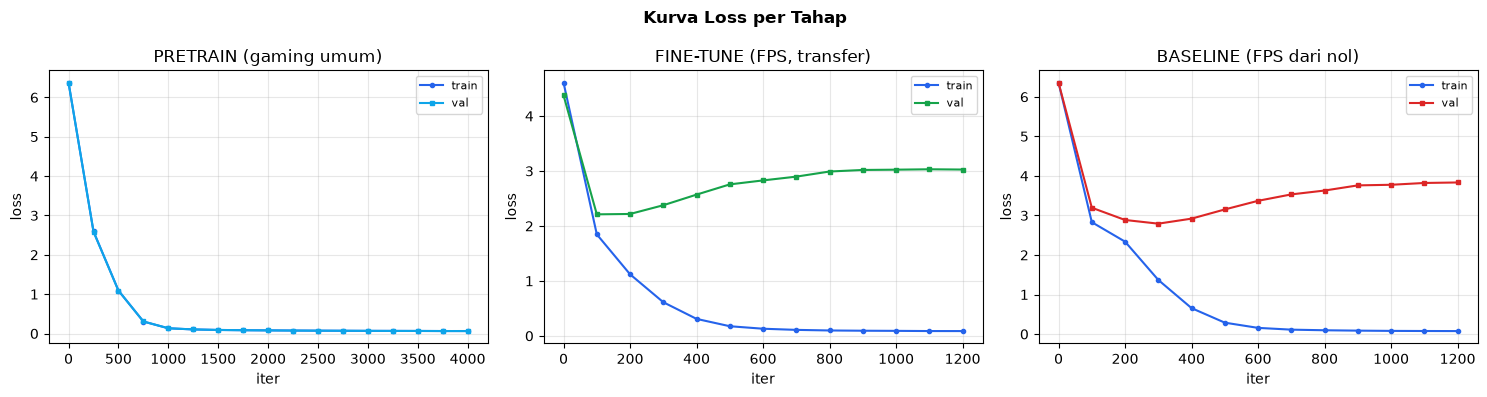

In [10]:
# Chart 1: kurva loss tiap tahap
fig,ax=plt.subplots(1,3,figsize=(15,4))
for a,(info,ttl,col) in zip(ax,[(pre_info,"PRETRAIN (gaming umum)","#0ea5e9"),
                                (ft_info,"FINE-TUNE (FPS, transfer)","#16a34a"),
                                (sc_info,"BASELINE (FPS dari nol)","#dc2626")]):
    it=[h[0] for h in info["history"]]; tr=[h[1] for h in info["history"]]; va=[h[2] for h in info["history"]]
    a.plot(it,tr,"-o",ms=3,label="train",color="#2563eb"); a.plot(it,va,"-s",ms=3,label="val",color=col)
    a.set_title(ttl); a.set_xlabel("iter"); a.set_ylabel("loss"); a.grid(alpha=.3); a.legend(fontsize=8)
fig.suptitle("Kurva Loss per Tahap",fontweight="bold"); fig.tight_layout()
fig.savefig(os.path.join(OUT,"chart_transfer_loss.png"),dpi=120,bbox_inches="tight"); plt.show()

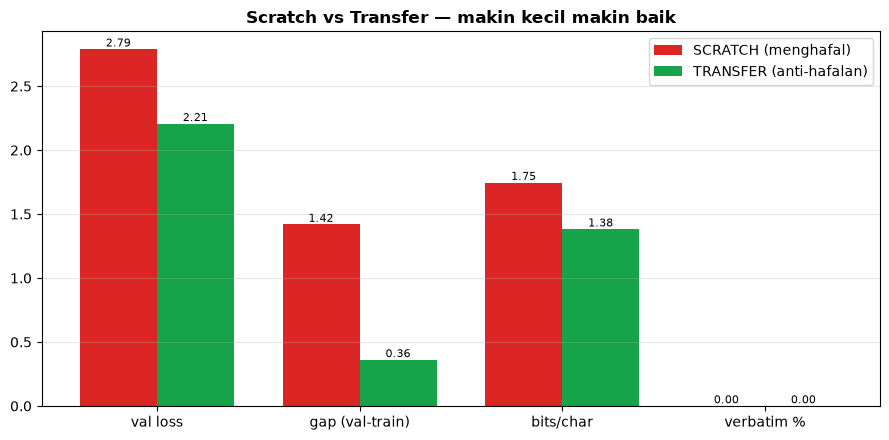

In [11]:
# Chart 2: perbandingan scratch vs transfer (gap, bits/char, verbatim%)
import numpy as np
labels=["val loss","gap (val-train)","bits/char","verbatim %"]
scr=[m_scr["val_loss"],m_scr["gap"],m_scr["bpc"],m_scr["verbatim"]]
ft =[m_ft["val_loss"], m_ft["gap"], m_ft["bpc"], m_ft["verbatim"]]
x=np.arange(len(labels)); w=0.38
fig,ax=plt.subplots(figsize=(9,4.5))
b1=ax.bar(x-w/2,scr,w,label="SCRATCH (menghafal)",color="#dc2626")
b2=ax.bar(x+w/2,ft, w,label="TRANSFER (anti-hafalan)",color="#16a34a")
for bars in (b1,b2):
    for b in bars: ax.text(b.get_x()+b.get_width()/2,b.get_height(),f"{b.get_height():.2f}",ha="center",va="bottom",fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_title("Scratch vs Transfer — makin kecil makin baik",fontweight="bold")
ax.legend(); ax.grid(axis="y",alpha=.3); fig.tight_layout()
fig.savefig(os.path.join(OUT,"chart_transfer_compare.png"),dpi=120,bbox_inches="tight"); plt.show()

## 11. Contoh Generate — Scratch vs Transfer (prompt sama)

In [12]:
for seed in ["game fps ","senjata "]:
    print("="*70); print("SEED:",repr(seed))
    print("[SCRATCH ]", gen_text(sc_model,seed,120).replace("\n"," ")[:340])
    print("[TRANSFER]", gen_text(ft_model,seed,120).replace("\n"," ")[:340])
    print()

SEED: 'game fps '


[SCRATCH ] game  fps  mensi  refleks , kesadaran  uang  waktu . sangat  penting  ketika  memaki  setiap  untuk  kompetitif . seberapa  memilih  pahlawan  terkenal  imeragen  bermain  terasa  hant  sering  sudut  dan  plekerja  dikan  ekonten . counaan  latih  pengaturan  yang  tepat  membantu  biasa  mobar  membawa  atau 


[TRANSFER] game  fps  memide . banyak  pemain  fena  menuntut  kompetitif , dan  ketegangan  mahkan  yang  diaturi  berpola  shan  atau  castisabaran  dengan  cepat . perkembangan  permainan  ini  juga  reaksi  dalam  genre  ini , setiap  tembakan  pengalaman  sebeda  bermain . dunia  konomis  atau  role  pertarungan  sering  menjadi  salah  satu  g

SEED: 'senjata '


[SCRATCH ] senjata  yang  baik . pemain  harus  tk  mengendalikan  fektif  performa  dengan  atau  cepat , jelomi  uang  sindari  ktur  detau  musuh  dan  eplin  bertahan  lingkungan  sama  mempopularitasukan  utama . peta  genre  fps  akan  pemain  realistivitas  subar  perlengkapan  mereka . banyak  six  mendukung  ke


[TRANSFER] senjata  setiap  orang , pemain . genre  fps  memiliki  melatih  ke  sangat  populer  dengan  tambah  mouse  yang  lebih  baik . banyak  permainan  fps  khususan  kesekk  belajar  untuk  berbeda . koordinasi  membuktis  atau  bagaimana  libatkan  pahlik  dari  refleksiaran  dikan  di  segrendah  yang  membahas  strategi  

